# Risk assessment for heavy snowfall & blizzards — Kazakhstan

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) SNOW risk workflow
for Kazakhstan using globally available datasets.

## Data Substitutions

| Original CLIMAAX (EU) | Kazakhstan Adaptation | Notes |
|---|---|---|
| EURO-CORDEX hazard files | ISIMIP3b hazard files (from snow_hazard_kazakhstan.py) | File names updated to match KZ hazard outputs |
| `xESMF` regridder | `xarray.DataArray.interp()` (linear) | xESMF requires ESMF — not available in crabook-kz; xarray interp is sufficient for 30″→0.25°/0.5° downscaling |
| GHSL population (JRC FTP) | Same GHSL GHS-POP 2015 dataset | Dataset is global — direct keep, only bbox changes |
| Alpine region subset (lon 4–15°E, lat 42–50°N) | Full Kazakhstan extent | No equivalent single high-density/high-hazard sub-region |
| `ccrs.Orthographic(0, 35)` | `ccrs.PlateCarree()` with KZ extent | Geographic adaptation |
| `drop_vars(['rotated_pole','height'])` | Removed | ISIMIP3b has no rotated-pole coordinates |
| `gl.xlabels_top` / `gl.ylabels_right` (deprecated) | `gl.top_labels` / `gl.right_labels` | API change in cartopy |

**Methodology preserved (no changes):**
- Change signal: `future − historical`, masked where `historical ≤ 1%`
- Population overlay: hazard indicator masked where population < 1 person/km²
- All indicator definitions and thresholds identical to hazard notebook

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
from pathlib import Path

import requests
import numpy as np
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Configuration — must match snow_hazard_kazakhstan.py

In [3]:
region_id   = 'KAZ'
region_name = 'Kazakhstan'

lat_north = 57.0
lat_south = 39.0
lon_west  = 45.0
lon_east  = 88.0

hist_start_year = 1991
hist_end_year   = 1995
fut_start_year  = 2046
fut_end_year    = 2050

gcm_models = [
    'GFDL-ESM4',
    'IPSL-CM6A-LR',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'UKESM1-0-LL',
]
gcm_choice   = 0
gcm_model    = gcm_models[gcm_choice]
ssp_scenario = 'ssp126'

work_dir = Path('SNOW_hazard')
data_dir = work_dir / f'data_{region_id}'
plot_dir = work_dir / f'plots_{region_id}'
repo_root = Path(r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook')
shp_path  = repo_root / 'KAZ_BORDER_VERSION_1/LVL3/SHP_LVL3/KAZ_OSM_BORDER_LVL3.shp'

for d in [data_dir, plot_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Model    : {gcm_model}")
print(f"Scenario : {ssp_scenario}")
print(f"Hist     : {hist_start_year}–{hist_end_year}")
print(f"Future   : {fut_start_year}–{fut_end_year}")

Model    : GFDL-ESM4
Scenario : ssp126
Hist     : 1991–1995
Future   : 2046–2050


## Load hazard outputs from snow_hazard_kazakhstan.py

In [4]:
# ---- ERA5 ----
blizzard_era5 = xr.open_dataset(
    data_dir / f'BdayCount_AnaProb_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')
snow6_era5    = xr.open_dataset(
    data_dir / f'Snow6Prob_annual_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')
snow25_era5   = xr.open_dataset(
    data_dir / f'Snow25Prob_annual_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')

# ---- ISIMIP3b historical ----
blizzard_hist = xr.open_dataarray(
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
snow6_hist    = xr.open_dataarray(
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
snow25_hist   = xr.open_dataarray(
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')

# ---- ISIMIP3b future ----
blizzard_fut  = xr.open_dataarray(
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc')
snow6_fut     = xr.open_dataarray(
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc')
snow25_fut    = xr.open_dataarray(
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc')

print('Hazard files loaded.')

Hazard files loaded.


## Compute change signal (future − historical)

Identical to the original workflow:
- `change = future − historical`
- Masked to zero where `historical ≤ 1%` (suppress noise in near-zero regions)
- No `drop_vars` needed — ISIMIP3b has no rotated-pole coordinates

In [5]:
def change_signal(fut_da, hist_da):
    change = fut_da - hist_da
    return change.where(hist_da > 1, other=0.0)

blizzard_change = change_signal(blizzard_fut,  blizzard_hist)
snow6_change    = change_signal(snow6_fut,     snow6_hist)
snow25_change   = change_signal(snow25_fut,    snow25_hist)

blizzard_change.name = 'blizzard_days'
snow6_change.name    = 'snow_days'
snow25_change.name   = 'snow_days'

print('Change signals computed.')

Change signals computed.


## Population data — GHSL GHS-POP 2015 (global, 30 arcsec)

Same source as the original CLIMAAX workflow. Dataset is global so no
substitution required — only the bounding box changes to Kazakhstan.

Download (~600 MB). Cached if already present.

In [6]:
ghsl_url  = (
    'https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/'
    'GHS_POP_GLOBE_R2023A/GHS_POP_E2015_GLOBE_R2023A_4326_30ss/'
    'V1-0/GHS_POP_E2015_GLOBE_R2023A_4326_30ss_V1_0.zip'
)
ghsl_tif  = data_dir / 'GHS_POP_E2015_GLOBE_R2023A_4326_30ss_V1_0.tif'
ghsl_zip  = data_dir / 'GHS_POP_E2015.zip'

if not ghsl_tif.exists():
    print('Downloading GHSL population (~600 MB)...')
    with requests.get(ghsl_url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(ghsl_zip, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f'\r  {downloaded / total * 100:.1f}%', end='', flush=True)
    print()
    with zipfile.ZipFile(ghsl_zip, 'r') as z:
        z.extractall(path=data_dir)
    ghsl_zip.unlink()
    print(f'GHSL extracted to {data_dir}')
else:
    print(f'Cached: {ghsl_tif.name}')

Cached: GHS_POP_E2015_GLOBE_R2023A_4326_30ss_V1_0.tif


## Process population data

### Clip to Kazakhstan and regrid

Original used `xESMF` (bilinear regridding). Replaced with `xarray.DataArray.interp()`
(linear interpolation) — methodologically equivalent for coarsening from 30″ to 0.25°/0.5°.

Two target grids:
- **ERA5** (0.25°): for ERA5 hazard overlay plots
- **ISIMIP3b** (0.5°): for ISIMIP3b historical/change overlay plots

In [7]:
pop_raw = rxr.open_rasterio(ghsl_tif, masked=True).squeeze('band', drop=True)
pop_raw = pop_raw.drop_vars('spatial_ref', errors='ignore')
pop_raw = pop_raw.rename({'x': 'longitude', 'y': 'latitude'})

# Clip to Kazakhstan + small buffer
pop_kz = pop_raw.sel(
    latitude=slice(lat_north + 0.5, lat_south - 0.5),
    longitude=slice(lon_west - 0.5, lon_east + 0.5),
)
# Replace nodata with 0
pop_kz = pop_kz.where(pop_kz > 0, other=0.0)
pop_kz.attrs = {'units': 'persons/km2', 'long_name': 'Population density 2015'}

# ---- Regrid to ERA5 grid (0.25°) ----
era5_lat = blizzard_era5.latitude.values
era5_lon = blizzard_era5.longitude.values
pop_era5 = pop_kz.interp(latitude=era5_lat, longitude=era5_lon, method='linear')
pop_era5 = pop_era5.where(pop_era5 > 0, other=0.0)
pop_era5.to_netcdf(data_dir / f'population_ERA5grid_{region_id}.nc')

# ---- Regrid to ISIMIP3b grid (0.5°) ----
isimip_lat = blizzard_hist.lat.values
isimip_lon = blizzard_hist.lon.values
pop_isimip = pop_kz.interp(latitude=isimip_lat, longitude=isimip_lon, method='linear')
pop_isimip = pop_isimip.where(pop_isimip > 0, other=0.0)
pop_isimip.to_netcdf(data_dir / f'population_ISIMIPgrid_{region_id}.nc')

print('Population regridded to ERA5 and ISIMIP3b grids.')

Population regridded to ERA5 and ISIMIP3b grids.


## Load Kazakhstan boundary

In [8]:
kz_gdf      = gpd.read_file(shp_path)
if kz_gdf.crs is None or kz_gdf.crs.to_epsg() != 4326:
    kz_gdf  = kz_gdf.to_crs(epsg=4326)
kz_national = kz_gdf.dissolve()

## Plotting functions

Unified for both ERA5 and ISIMIP3b (both now on regular lat/lon grids).
Two functions matching the original structure:
- `plot_map_kz`: single-variable map (replaces `plot_map_ERA5` and `plot_map_CORDEX`)
- `plot_overlay_kz`: hazard + population overlay (replaces `plot_overlay_map`)

In [9]:
KZ_EXTENT = [lon_west - 1, lon_east + 1, lat_south - 1, lat_north + 1]

def _add_kz_features(ax, kz_national):
    ax.set_extent(KZ_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN,   facecolor='aliceblue', edgecolor='black', linewidth=0.3)
    ax.add_feature(cfeature.LAND,    facecolor='none',      edgecolor='black', linewidth=0.3)
    kz_national.boundary.plot(ax=ax, color='black', linewidth=1.2,
                              transform=ccrs.PlateCarree())
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.7, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False


def plot_map_kz(var_da, p_levels, cmap, title, cb_label, outfile, kz_national,
                lat_dim='latitude', lon_dim='longitude'):
    """Single-variable hazard probability map for Kazakhstan."""
    fig, ax = plt.subplots(figsize=(12, 7),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    p = var_da.plot.contourf(ax=ax, x=lon_dim, y=lat_dim,
                             levels=p_levels, cmap=cmap,
                             transform=ccrs.PlateCarree(),
                             add_colorbar=False)
    _add_kz_features(ax, kz_national)
    cbar = fig.colorbar(p, ax=ax, location='right', shrink=0.6, pad=0.05)
    cbar.set_label(cb_label)
    ax.set_title(title, loc='left', fontsize=10)
    plt.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {Path(outfile).name}')


def plot_overlay_kz(hazard_da, pop_da, hz_levels, pop_levels,
                    hz_cmap, pop_cmap, title, hz_cb_label, pop_cb_label,
                    outfile, kz_national,
                    hz_lat='latitude', hz_lon='longitude',
                    pop_lat='latitude', pop_lon='longitude'):
    """
    Overlay plot: hazard (contourf) + population (pcolormesh).
    Matches original plot_overlay_map structure.
    """
    fig, ax = plt.subplots(figsize=(14, 8),
                           subplot_kw={'projection': ccrs.PlateCarree()})

    p_hz  = hazard_da.plot.contourf(ax=ax, x=hz_lon,  y=hz_lat,
                                    levels=hz_levels, cmap=hz_cmap,
                                    transform=ccrs.PlateCarree(),
                                    alpha=0.6, add_colorbar=False)
    p_pop = pop_da.plot.pcolormesh(ax=ax, x=pop_lon, y=pop_lat,
                                   levels=pop_levels, cmap=pop_cmap,
                                   transform=ccrs.PlateCarree(),
                                   alpha=0.5, add_colorbar=False)

    _add_kz_features(ax, kz_national)
    ax.set_title(title, loc='left', fontsize=10)

    cbar_pop = fig.colorbar(p_pop, ax=ax, location='left',  shrink=0.5, pad=0.05)
    cbar_pop.set_label(pop_cb_label)
    cbar_hz  = fig.colorbar(p_hz,  ax=ax, location='right', shrink=0.5, pad=0.05)
    cbar_hz.set_label(hz_cb_label)

    plt.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {Path(outfile).name}')

## Plot 1 — Population density map

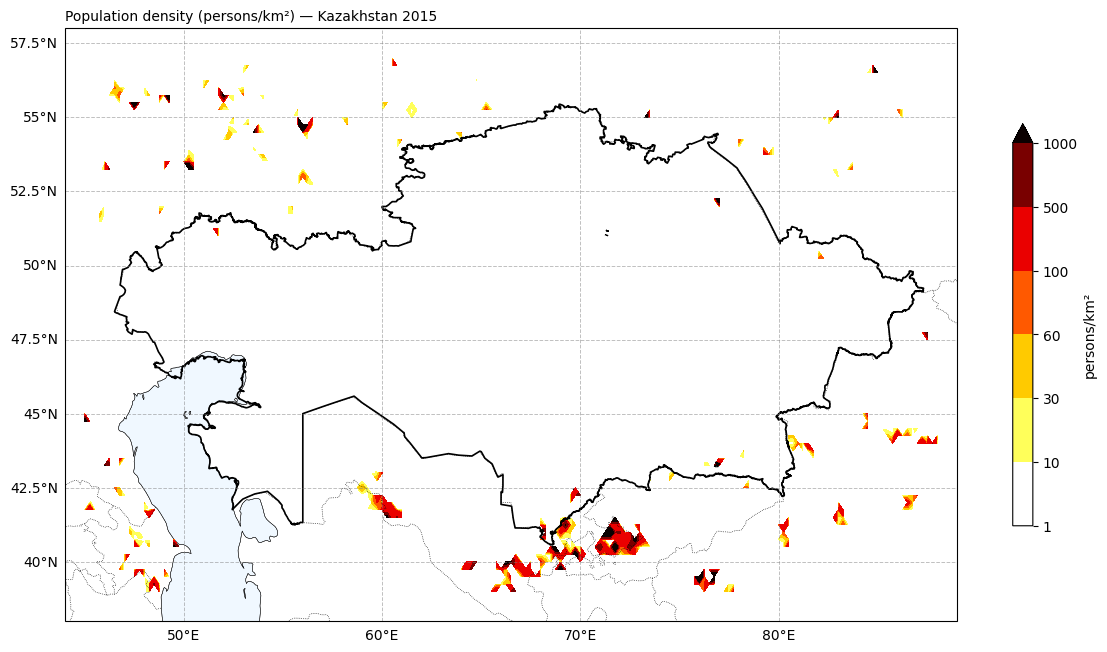

Saved: Population_density_KAZ.png


In [10]:
plot_map_kz(
    var_da   = pop_era5.where(pop_era5 >= 1),
    p_levels = [1, 10, 30, 60, 100, 500, 1000],
    cmap     = 'hot_r',
    title    = f'Population density (persons/km²) — {region_name} 2015',
    cb_label = 'persons/km²',
    outfile  = plot_dir / f'Population_density_{region_id}.png',
    kz_national = kz_national,
)

## Plot 2 — ERA5 historical hazard maps (standalone)

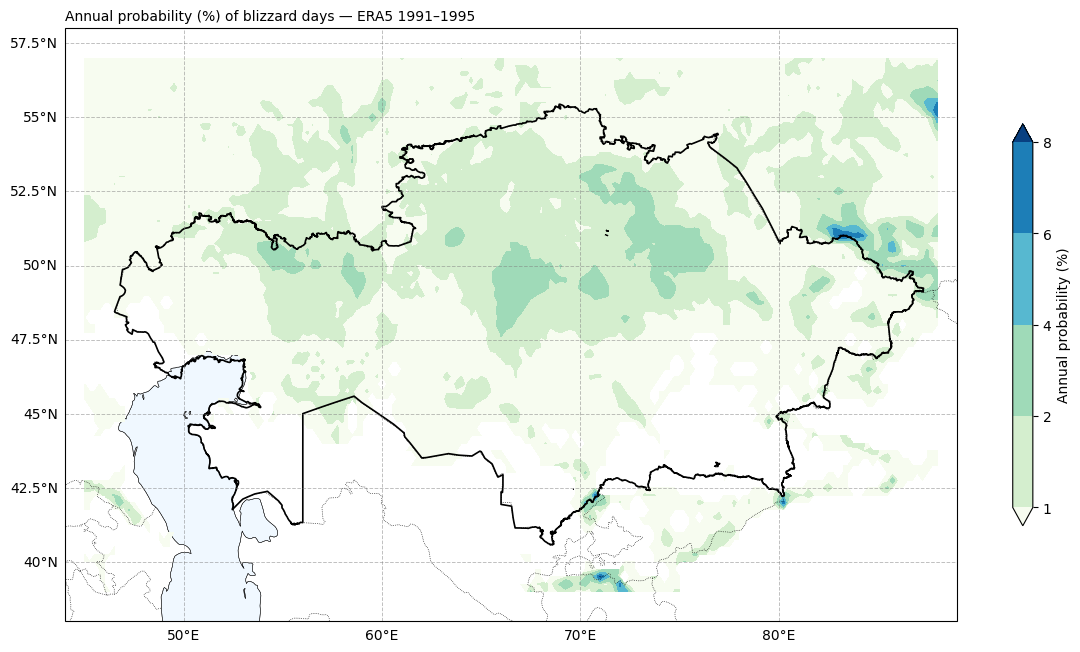

Saved: blizzard_ERA5_1991_1995.png


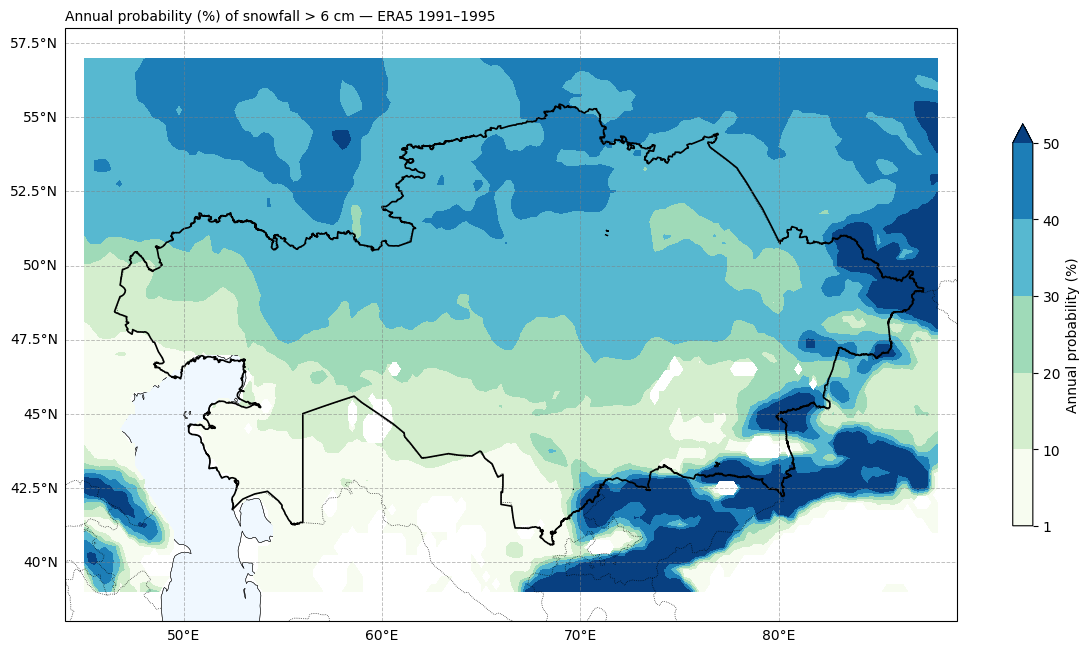

Saved: snow6cm_ERA5_1991_1995.png


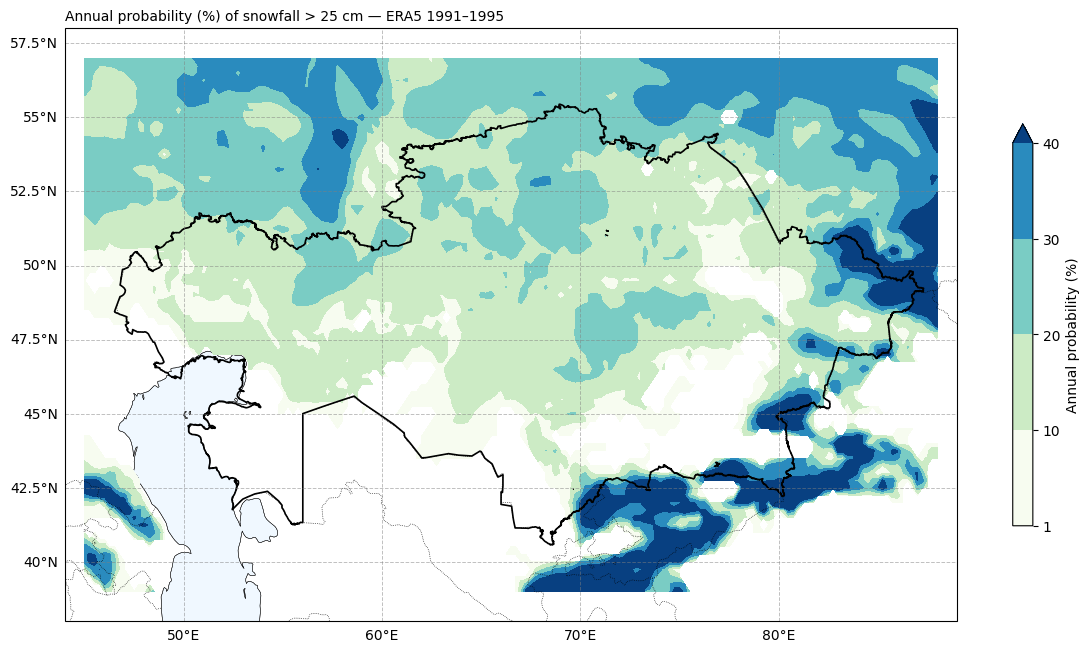

Saved: snow25cm_ERA5_1991_1995.png


In [11]:
plot_map_kz(
    blizzard_era5.blizzard_days,
    p_levels=[1, 2, 4, 6, 8], cmap='GnBu',
    title=f'Annual probability (%) of blizzard days — ERA5 {hist_start_year}–{hist_end_year}',
    cb_label='Annual probability (%)',
    outfile=plot_dir / f'blizzard_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

plot_map_kz(
    snow6_era5.snow_days.where(snow6_era5.snow_days >= 1),
    p_levels=[1, 10, 20, 30, 40, 50], cmap='GnBu',
    title=f'Annual probability (%) of snowfall > 6 cm — ERA5 {hist_start_year}–{hist_end_year}',
    cb_label='Annual probability (%)',
    outfile=plot_dir / f'snow6cm_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

plot_map_kz(
    snow25_era5.snow_days.where(snow25_era5.snow_days >= 1),
    p_levels=[1, 10, 20, 30, 40], cmap='GnBu',
    title=f'Annual probability (%) of snowfall > 25 cm — ERA5 {hist_start_year}–{hist_end_year}',
    cb_label='Annual probability (%)',
    outfile=plot_dir / f'snow25cm_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

## Plot 3 — ERA5 hazard × population overlay

Snow indicators masked where population < 1 person/km².
Matches the original risk workflow overlay structure.

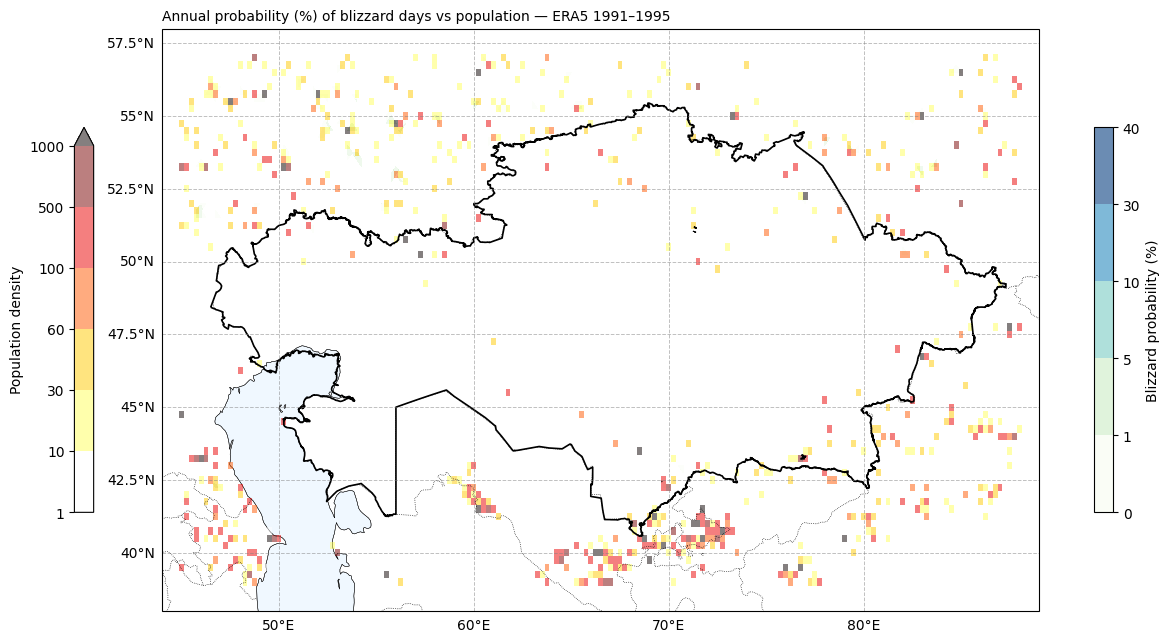

Saved: overlay_blizzard_ERA5_1991_1995.png


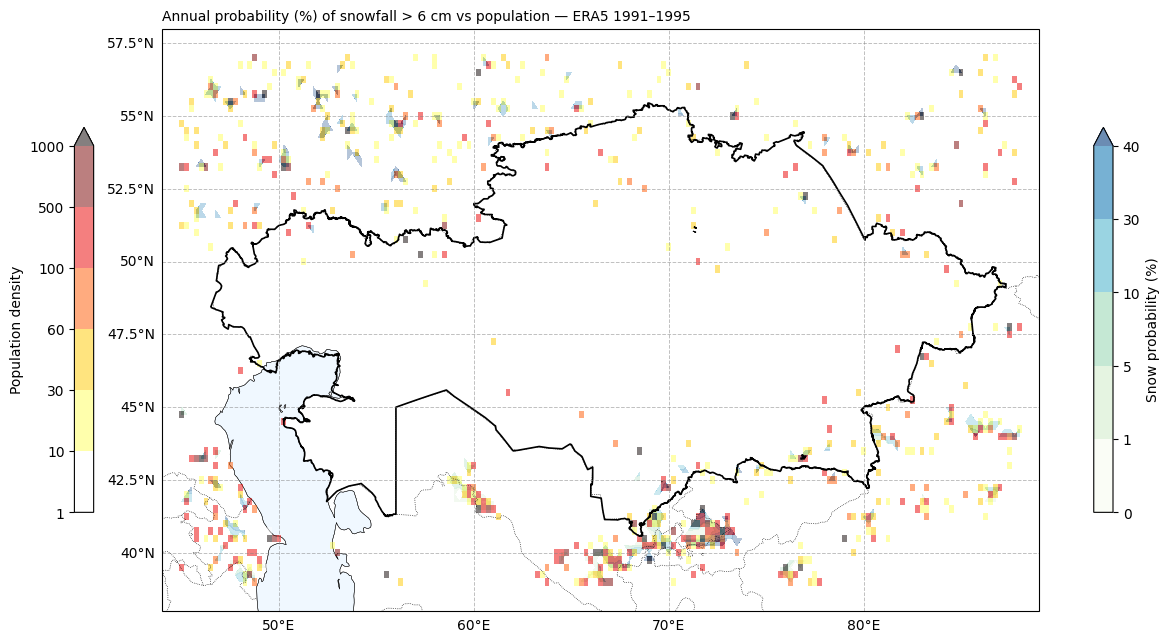

Saved: overlay_snow6cm_ERA5_1991_1995.png


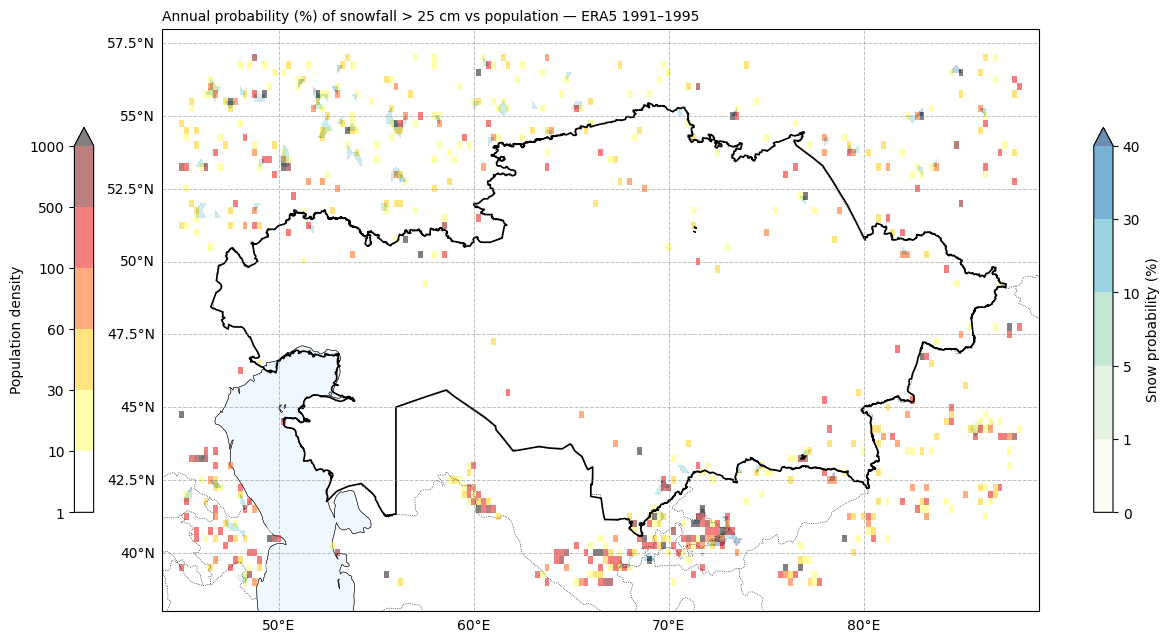

Saved: overlay_snow25cm_ERA5_1991_1995.png


In [12]:
# Mask: show hazard only where population is present
blizzard_era5_masked = blizzard_era5.blizzard_days.where(pop_era5 >= 1)
snow6_era5_masked    = snow6_era5.snow_days.where(pop_era5 >= 1)
snow25_era5_masked   = snow25_era5.snow_days.where(pop_era5 >= 1)
pop_era5_blizzard    = pop_era5.where(blizzard_era5.blizzard_days > 0)

# Blizzard
plot_overlay_kz(
    hazard_da=blizzard_era5_masked, pop_da=pop_era5.where(pop_era5 >= 1),
    hz_levels=[0, 1, 5, 10, 30, 40], pop_levels=[1, 10, 30, 60, 100, 500, 1000],
    hz_cmap='GnBu', pop_cmap='hot_r',
    title=f'Annual probability (%) of blizzard days vs population — ERA5 {hist_start_year}–{hist_end_year}',
    hz_cb_label='Blizzard probability (%)', pop_cb_label='Population density',
    outfile=plot_dir / f'overlay_blizzard_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# Snow > 6 cm
plot_overlay_kz(
    hazard_da=snow6_era5_masked, pop_da=pop_era5.where(pop_era5 >= 1),
    hz_levels=[0, 1, 5, 10, 30, 40], pop_levels=[1, 10, 30, 60, 100, 500, 1000],
    hz_cmap='GnBu', pop_cmap='hot_r',
    title=f'Annual probability (%) of snowfall > 6 cm vs population — ERA5 {hist_start_year}–{hist_end_year}',
    hz_cb_label='Snow probability (%)', pop_cb_label='Population density',
    outfile=plot_dir / f'overlay_snow6cm_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# Snow > 25 cm
plot_overlay_kz(
    hazard_da=snow25_era5_masked, pop_da=pop_era5.where(pop_era5 >= 1),
    hz_levels=[0, 1, 5, 10, 30, 40], pop_levels=[1, 10, 30, 60, 100, 500, 1000],
    hz_cmap='GnBu', pop_cmap='hot_r',
    title=f'Annual probability (%) of snowfall > 25 cm vs population — ERA5 {hist_start_year}–{hist_end_year}',
    hz_cb_label='Snow probability (%)', pop_cb_label='Population density',
    outfile=plot_dir / f'overlay_snow25cm_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

## Plot 4 — ISIMIP3b change signal × population overlay

Change = SSP future − historical, masked where historical ≤ 1%.
Population on ISIMIP3b 0.5° grid.

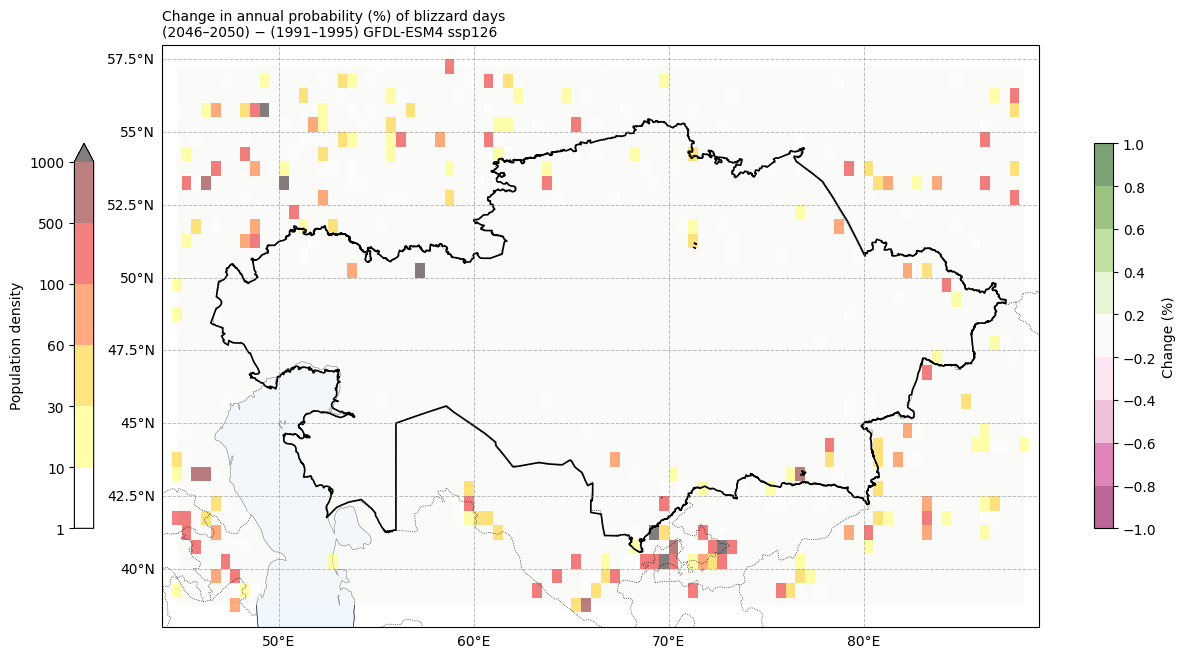

Saved: overlay_blizzard_change_GFDL-ESM4_ssp126_2046_2050.png


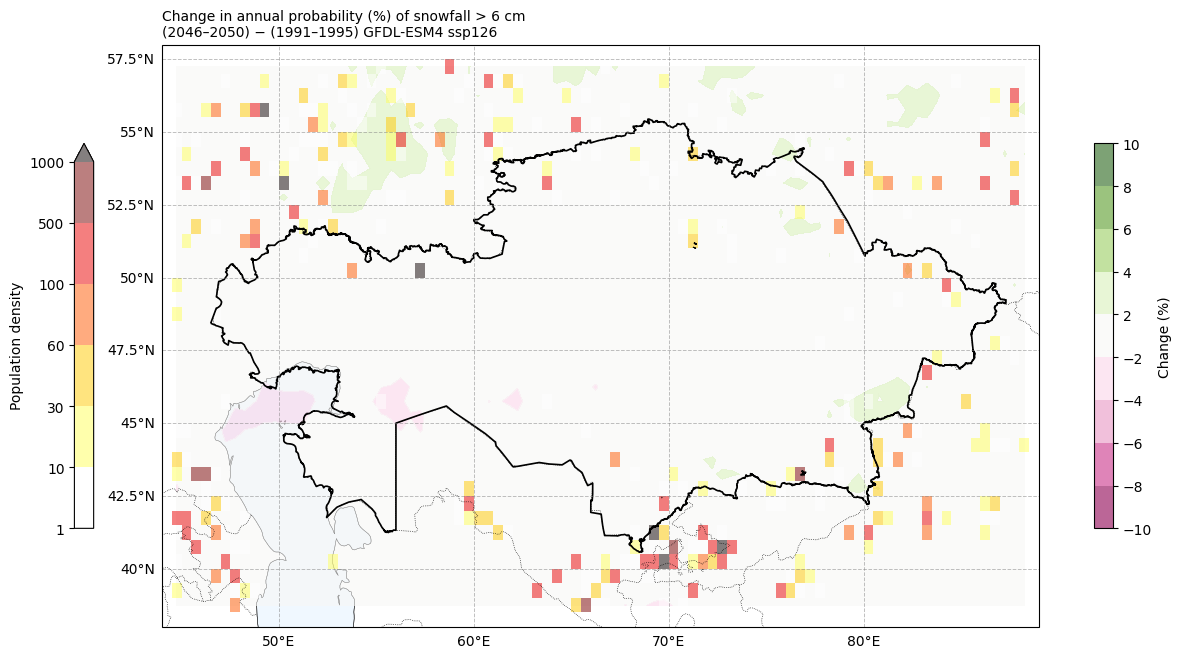

Saved: overlay_snow6cm_change_GFDL-ESM4_ssp126_2046_2050.png


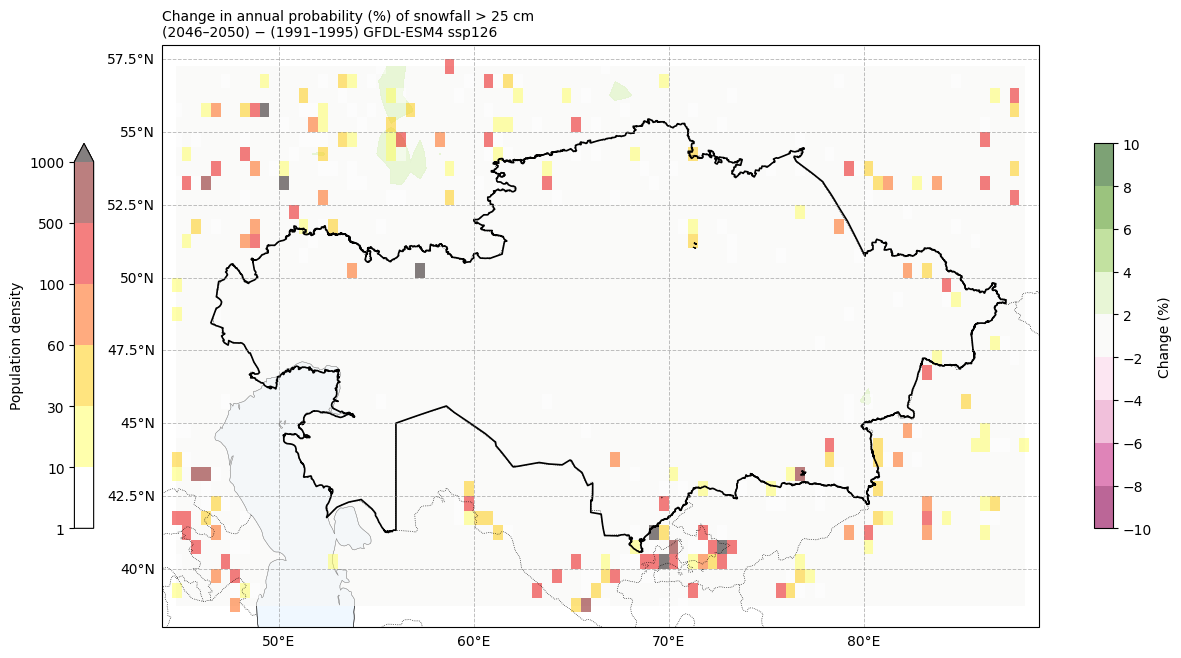

Saved: overlay_snow25cm_change_GFDL-ESM4_ssp126_2046_2050.png


In [13]:
plot_overlay_kz(
    hazard_da=blizzard_change, pop_da=pop_isimip.where(pop_isimip >= 1),
    hz_levels=[-1, -0.8, -0.6, -0.4, -0.2, 0.2, 0.4, 0.6, 0.8, 1],
    pop_levels=[1, 10, 30, 60, 100, 500, 1000],
    hz_cmap='PiYG', pop_cmap='hot_r',
    title=(f'Change in annual probability (%) of blizzard days\n'
           f'({fut_start_year}–{fut_end_year}) − ({hist_start_year}–{hist_end_year}) '
           f'{gcm_model} {ssp_scenario}'),
    hz_cb_label='Change (%)', pop_cb_label='Population density',
    outfile=plot_dir / f'overlay_blizzard_change_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.png',
    kz_national=kz_national,
    hz_lat='lat', hz_lon='lon',
    pop_lat='latitude', pop_lon='longitude',
)

plot_overlay_kz(
    hazard_da=snow6_change, pop_da=pop_isimip.where(pop_isimip >= 1),
    hz_levels=[-10, -8, -6, -4, -2, 2, 4, 6, 8, 10],
    pop_levels=[1, 10, 30, 60, 100, 500, 1000],
    hz_cmap='PiYG', pop_cmap='hot_r',
    title=(f'Change in annual probability (%) of snowfall > 6 cm\n'
           f'({fut_start_year}–{fut_end_year}) − ({hist_start_year}–{hist_end_year}) '
           f'{gcm_model} {ssp_scenario}'),
    hz_cb_label='Change (%)', pop_cb_label='Population density',
    outfile=plot_dir / f'overlay_snow6cm_change_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.png',
    kz_national=kz_national,
    hz_lat='lat', hz_lon='lon',
    pop_lat='latitude', pop_lon='longitude',
)

plot_overlay_kz(
    hazard_da=snow25_change, pop_da=pop_isimip.where(pop_isimip >= 1),
    hz_levels=[-10, -8, -6, -4, -2, 2, 4, 6, 8, 10],
    pop_levels=[1, 10, 30, 60, 100, 500, 1000],
    hz_cmap='PiYG', pop_cmap='hot_r',
    title=(f'Change in annual probability (%) of snowfall > 25 cm\n'
           f'({fut_start_year}–{fut_end_year}) − ({hist_start_year}–{hist_end_year}) '
           f'{gcm_model} {ssp_scenario}'),
    hz_cb_label='Change (%)', pop_cb_label='Population density',
    outfile=plot_dir / f'overlay_snow25cm_change_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.png',
    kz_national=kz_national,
    hz_lat='lat', hz_lon='lon',
    pop_lat='latitude', pop_lon='longitude',
)

## Conclusions

This workflow has illustrated the process of overlaying heavy snowfall and blizzard
hazard indicators with population exposure for Kazakhstan, mirroring the original
CLIMAAX SNOW risk structure.

**Kazakhstan-specific interpretation notes:**
- Population centres most exposed to snow hazard are in northern Kazakhstan
  (Petropavl, Kostanay, Astana) and the Almaty region (Tian Shan foothills).
- ERA5 observational baseline provides the most reliable present-day picture;
  ISIMIP3b historical tends to underestimate extreme snow frequency at 0.5°.
- The change signal should be interpreted cautiously for 5-year demonstration
  periods — extend to 30 years for climatologically robust results.
- A multi-model ensemble (all 5 ISIMIP3b GCMs) is recommended to account
  for model uncertainty in projected changes.
- Blizzard days (*buran/zhut*) are most likely underestimated: the 17 m/s
  mean wind speed threshold is conservative relative to recorded buran events.
  Results serve as a lower-bound estimate of exposure.

Output plots are saved to `{plot_dir}`.